# Phase 3 CRISP-DM — Data Preparation
**Project:** Customer Behavior Analysis — Olist Brazilian E-Commerce
**Goal:** Build the master table (`olist_master.csv`) with clean variables and business features ready for modeling.

The EDA (notebook 01) revealed the quality issues we address here:
- Nulls in delivery dates → filter to `delivered` orders with complete dates only
- 88% of `review_comment_title` empty → we drop free text, use score only
- 261K duplicates in `geolocation` → not used in the master table
- Categories in Portuguese → translate to English via `category_translation`

---


## 0. Imports and configuration

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ROOT   = Path().resolve().parent
DB_PATH = ROOT / "data" / "olist.db"
OUT_CSV = ROOT / "data" / "olist_master.csv"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)

print(f"DB:     data/{DB_PATH.name}  ->  exists: {DB_PATH.exists()}")
print(f"Output: data/{OUT_CSV.name}")

DB:     data/olist.db  ->  exists: True
Output: data/olist_master.csv


---
## 1. Loading tables from SQLite
We load only the tables needed for the master table. `geolocation` is skipped because its duplicates make it of little use without prior deduplication, and it is not needed for satisfaction modeling.

In [2]:
conn = sqlite3.connect(DB_PATH)

orders       = pd.read_sql("SELECT * FROM orders",               conn)
order_items  = pd.read_sql("SELECT * FROM order_items",          conn)
reviews      = pd.read_sql("SELECT * FROM order_reviews",        conn)
customers    = pd.read_sql("SELECT * FROM customers",            conn)
products     = pd.read_sql("SELECT * FROM products",             conn)
translation  = pd.read_sql("SELECT * FROM category_translation", conn)

conn.close()

print(f"orders:      {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"reviews:     {reviews.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"translation: {translation.shape}")

orders:      (99441, 8)
order_items: (112650, 7)
reviews:     (99224, 7)
customers:   (99441, 5)
products:    (32951, 9)
translation: (71, 2)


---
## 2. Data cleaning

### 2.1 Order filter: `delivered` only, with complete dates
**Business decision:** Only delivered orders have a real delivery date, which is the key variable for computing the delay (`delivery_delay_days`) and correlating it with customer satisfaction.
Orders in other statuses (cancelled, in transit) are not comparable and could bias the model.

In [3]:
n_total = len(orders)

# Step 1: filter by status
orders_del = orders[orders["order_status"] == "delivered"].copy()
print(f"Delivered:          {len(orders_del):>7,}  ({len(orders_del)/n_total*100:.1f}% of total)")

# Step 2: parse all date columns
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders_del[col] = pd.to_datetime(orders_del[col], errors="coerce")

# Step 3: drop rows missing the essential dates
# order_delivered_customer_date -> real date (to compute delay)
# order_estimated_delivery_date -> promised date (for comparison)
# order_purchase_timestamp      -> order origin (for delivery_days)
critical_dates = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
orders_del.dropna(subset=critical_dates, inplace=True)
print(f"With critical dates:{len(orders_del):>7,}  ({len(orders_del)/n_total*100:.1f}% of total)")

Delivered:           96,478  (97.0% of total)
With critical dates: 96,470  (97.0% of total)


### 2.2 Date parsing in `order_items`
`shipping_limit_date` can have null or malformed values. We parse it for schema consistency, although we don't use it as a feature in this phase.

In [4]:
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"], errors="coerce"
)
print(f"order_items dtypes:\n{order_items.dtypes}")

order_items dtypes:
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object


### 2.3 Review deduplication
The EDA showed that `order_reviews` can have multiple reviews for the same `order_id` (due to system retries). For the 1-to-1 join with orders, we keep the most recent review by `review_answer_timestamp`.

In [5]:
reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"], errors="coerce"
)
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"], errors="coerce"
)

n_reviews_raw = len(reviews)
reviews_dedup = (
    reviews
    .sort_values("review_answer_timestamp", ascending=False)
    .drop_duplicates(subset="order_id", keep="first")  # most recent first
    # review_creation_date is kept (previously dropped) to check in section
    # 4.1b whether the review was written before or after the actual
    # delivery -- possible temporal leakage in the driver analysis (Phase 4).
    [["order_id", "review_score", "review_creation_date"]]
)

print(f"Total reviews:         {n_reviews_raw:,}")
print(f"Deduplicated reviews:  {len(reviews_dedup):,}")
print(f"Removed:               {n_reviews_raw - len(reviews_dedup):,}")

Total reviews:         99,224
Deduplicated reviews:  98,673
Removed:               551


### 2.4 Translating categories to English
We join `products` with `category_translation`. Products with no assigned category (610 cases detected in the EDA) get the value `'unknown'` so we don't lose those orders in later joins.

In [6]:
# Rename the translation column for clarity
translation = translation.rename(
    columns={"product_category_name_english": "category_en"}
)

products_cat = products[["product_id", "product_category_name", "product_weight_g"]].merge(
    translation, on="product_category_name", how="left"
)

# Fill untranslated categories with 'unknown'
products_cat["category_en"] = products_cat["category_en"].fillna("unknown")

print(f"Products with no translated category: {products_cat['category_en'].eq('unknown').sum()}")
print(f"Unique English categories:            {products_cat['category_en'].nunique()}")

Products with no translated category: 623
Unique English categories:            72


---
## 3. Merging tables
We build the master table in two steps:
1. Aggregate `order_items` to `order_id` level (from multiple rows to one per order)
2. Perform the successive joins around `orders`

### 3.1 Aggregating order_items to order level
Each order can have several items (different products). We need one row per order, so we aggregate with sums and counts.

In [7]:
items_agg = order_items.groupby("order_id", as_index=False).agg(
    n_items        =("order_item_id",  "count"),   # number of items in the order
    price_total    =("price",          "sum"),      # total product value
    freight_total  =("freight_value",  "sum"),      # total logistics cost
    product_id     =("product_id",     "first"),    # main product (first item)
    seller_id      =("seller_id",      "first"),    # main seller
)

print(f"items_agg shape: {items_agg.shape}")
print(items_agg.dtypes)

items_agg shape: (98666, 6)
order_id          object
n_items            int64
price_total      float64
freight_total    float64
product_id        object
seller_id         object
dtype: object


### 3.2 Central join
The join follows the same logic as the SQL in `sql/02_data_preparation.sql`:
- `INNER JOIN` with items and customers (must always exist)
- `LEFT JOIN` with reviews (not every order has a review)
- `LEFT JOIN` with product category (can be unknown)

In [8]:
# Base: delivered orders with dates
master = orders_del.copy()

# + aggregated items (inner: every order must have at least one item)
master = master.merge(items_agg, on="order_id", how="inner")

# + main product's category (left: unknown if missing)
master = master.merge(
    products_cat[["product_id", "category_en", "product_weight_g"]],
    on="product_id", how="left"
)

# + deduplicated review (left: not every order has a review)
master = master.merge(reviews_dedup, on="order_id", how="left")

# + customer data (inner: every order must have a customer)
customers_slim = customers[["customer_id", "customer_unique_id",
                             "customer_city", "customer_state"]]
master = master.merge(customers_slim, on="customer_id", how="inner")

print(f"Master table before feature engineering: {master.shape}")
print(f"\nNulls per column:")
print(master.isnull().sum()[master.isnull().sum() > 0])

Master table before feature engineering: (96470, 20)

Nulls per column:
order_approved_at                14
order_delivered_carrier_date      1
product_weight_g                 16
review_score                    646
review_creation_date            646
dtype: int64


---
## 4. Feature Engineering
We build the derived variables the model will need.

### 4.1 `delivery_delay_days` — Delivery delay
**Formula:** `actual_delivery_date − estimated_delivery_date` (in days)
- **Positive value:** the order arrived late → negative experience
- **Negative value:** the order arrived earlier than promised → positive experience
- **Zero value:** on time

This variable is the strongest candidate predictor of `review_score` according to the EDA correlation.

In [9]:
master["delivery_days"] = (
    master["order_delivered_customer_date"] - master["order_purchase_timestamp"]
).dt.days

master["delivery_delay_days"] = (
    master["order_delivered_customer_date"] - master["order_estimated_delivery_date"]
).dt.days

# Drop records with delivery_days <= 0: corrupt data where the delivery
# date is before or equal to the purchase date (impossible in production)
n_before = len(master)
master = master[master["delivery_days"] > 0].copy()
print(f"Records removed (delivery_days <= 0): {n_before - len(master)}")

print(f"\ndelivery_delay_days — statistics:")
print(master["delivery_delay_days"].describe().round(1))

Records removed (delivery_days <= 0): 13

delivery_delay_days — statistics:


count    96457.0
mean       -11.9
std         10.2
min       -147.0
25%        -17.0
50%        -12.0
75%         -7.0
max        188.0
Name: delivery_delay_days, dtype: float64


### 4.1b `review_before_delivery` — Temporal precedence check (portfolio review, priority 4)

**Decision:** before using `delivery_days`/`delivery_delay_days` as drivers of `review_score`
in Phase 4, we need to check that the review was written **after** the order arrived —
otherwise the predictor didn't exist yet at the moment the customer gave their opinion (temporal
leakage). In Olist the satisfaction survey is triggered on the **estimated** delivery date, not the
actual one, so for late orders it is plausible that the customer reviews *while still waiting*,
before receiving the package.

In [10]:
master["review_before_delivery"] = (
    master["review_creation_date"] < master["order_delivered_customer_date"]
)
# only meaningful for orders with a review
mask_reviewed = master["review_score"].notna()

pct_global = master.loc[mask_reviewed, "review_before_delivery"].mean()
delayed_mask = mask_reviewed & (master["delivery_delay_days"] > 0)
pct_delayed = master.loc[delayed_mask, "review_before_delivery"].mean()

print(f"Reviews written BEFORE the actual delivery (global, n={mask_reviewed.sum():,}): {pct_global:.1%}")
print(f"Reviews written BEFORE the actual delivery | delayed order "
      f"(n={delayed_mask.sum():,}): {pct_delayed:.1%}")

# How many of those were already written AFTER the promised date (waiting, knowing it was late)?
before_and_delayed = master[delayed_mask & master["review_before_delivery"]]
pct_after_estimate = (
    before_and_delayed["review_creation_date"] > before_and_delayed["order_estimated_delivery_date"]
).mean()
print(f"Of those, written after the PROMISED date already passed (waiting, knowing it was late): "
      f"{pct_after_estimate:.1%}")

Reviews written BEFORE the actual delivery (global, n=95,811): 8.5%
Reviews written BEFORE the actual delivery | delayed order (n=6,381): 83.6%
Of those, written after the PROMISED date already passed (waiting, knowing it was late): 98.9%


**Interpretation:** 83.6% of delayed orders have their review written before the actual delivery,
and 98.9% of those were already written after the promised date had passed. In other words, most
negative reviews associated with "delay" are not a reaction to *receiving* the order late, but to
*waiting* for an order the customer already knows didn't arrive on time — a different and weaker
mechanism than what "delivery delay causes dissatisfaction" suggests. Phase 4 (notebook 03) isolates
the **clean** subset (review written after delivery, with no temporal leakage) to measure the real
effect of the already-completed delivery experience, instead of mixing it with the frustration of
waiting. `review_before_delivery` is kept in the final table so that analysis can filter on it.

### 4.2 `is_negative_review` — Negative review flag
**Decision:** Scores 1 and 2 represent clear dissatisfaction (a common threshold in e-commerce).
Score 3 is neutral and is not included as negative. Orders with no review get `NaN` (we don't impute: absence of a review ≠ satisfaction).

In [11]:
master["is_negative_review"] = (master["review_score"] <= 2).astype("Int8")
# Nullable Int8: allows NaN where there is no review
master.loc[master["review_score"].isna(), "is_negative_review"] = pd.NA

# Distribution
neg = master["is_negative_review"].value_counts(dropna=False)
print("is_negative_review:")
print(f"  Negative (1): {neg.get(1, 0):,}  ({neg.get(1, 0)/len(master)*100:.1f}%)")
print(f"  Positive (0): {neg.get(0, 0):,}  ({neg.get(0, 0)/len(master)*100:.1f}%)")
print(f"  No review:    {master['is_negative_review'].isna().sum():,}  ({master['is_negative_review'].isna().sum()/len(master)*100:.1f}%)")

is_negative_review:
  Negative (1): 12,271  (12.7%)
  Positive (0): 83,540  (86.6%)
  No review:    646  (0.7%)


### 4.3 `order_month` — Purchase month
Captures seasonality: the EDA showed Nov 2017 had a peak (Black Friday Brazil). This variable lets the model learn temporal patterns.

In [12]:
master["order_month"]   = master["order_purchase_timestamp"].dt.to_period("M").astype(str)
master["order_weekday"] = master["order_purchase_timestamp"].dt.dayofweek  # 0=Monday, 6=Sunday
master["order_hour"]    = master["order_purchase_timestamp"].dt.hour

print("order_month — first unique values:")
print(sorted(master["order_month"].unique())[:8])

order_month — first unique values:
['2016-09', '2016-10', '2016-12', '2017-01', '2017-02', '2017-03', '2017-04', '2017-05']


### 4.4 `freight_ratio` — Freight / product price ratio
Indicates what fraction of the spend was logistics. A high ratio may indicate cheap products with expensive shipping (impacting perceived value).

In [13]:
master["freight_ratio"] = (master["freight_total"] / master["price_total"].replace(0, np.nan)).round(4)

print("freight_ratio — statistics:")
print(master["freight_ratio"].describe().round(3))

freight_ratio — statistics:
count    96457.000
mean         0.308
std          0.312
min          0.000
25%          0.132
50%          0.224
75%          0.381
max         21.447
Name: freight_ratio, dtype: float64


---
## 5. Master table validation
We review the final quality: correct data types, expected residual nulls, valid ranges.

In [14]:
# Column selection and order for the final table
final_cols = [
    "order_id",
    "customer_unique_id",
    "customer_state",
    "customer_city",
    "order_purchase_timestamp",
    "order_month",
    "order_weekday",
    "order_hour",
    "category_en",
    "n_items",
    "price_total",
    "freight_total",
    "freight_ratio",
    "product_weight_g",
    "delivery_days",
    "delivery_delay_days",
    "review_score",
    "is_negative_review",
    "review_creation_date",
    "review_before_delivery",
]

master_final = master[final_cols].copy()

print(f"Final shape: {master_final.shape}")
print(f"\nDtypes:")
print(master_final.dtypes)
print(f"\nResidual nulls:")
nulls = master_final.isnull().sum()
print(nulls[nulls > 0])

Final shape: (96457, 20)

Dtypes:
order_id                            object
customer_unique_id                  object
customer_state                      object
customer_city                       object
order_purchase_timestamp    datetime64[ns]
order_month                         object
order_weekday                        int32
order_hour                           int32
category_en                         object
n_items                              int64
price_total                        float64
freight_total                      float64
freight_ratio                      float64
product_weight_g                   float64
delivery_days                        int64
delivery_delay_days                  int64
review_score                       float64
is_negative_review                    Int8
review_creation_date        datetime64[ns]
review_before_delivery                bool
dtype: object

Residual nulls:
product_weight_g         16
review_score            646
is_negative_review 

In [15]:
# Integrity checks
assert master_final["order_id"].nunique() == len(master_final), "order_id is not unique!"
assert (master_final["delivery_days"] > 0).all(), "There are delivery_days <= 0"
assert master_final["review_score"].dropna().between(1, 5).all(), "review_score out of range"
assert master_final["price_total"].ge(0).all(), "There are negative price_total values"

print("All integrity checks passed.")
print(f"\nStatistical summary of key features:")
display(master_final[["delivery_days", "delivery_delay_days",
                       "price_total", "freight_ratio",
                       "review_score", "n_items"]].describe().round(2))

All integrity checks passed.

Statistical summary of key features:


,delivery_days,delivery_delay_days,price_total,freight_ratio,review_score,n_items
count,96457.00,96457.00,96457.00,96457.00,95811.00,96457.00
mean,12.10,-11.88,137.04,0.31,4.16,1.14
std,9.55,10.18,209.06,0.31,1.28,0.54
min,1.00,-147.00,0.85,0.00,1.00,1.00
25%,6.00,-17.00,45.90,0.13,4.00,1.00
50%,10.00,-12.00,86.50,0.22,5.00,1.00
75%,15.00,-7.00,149.90,0.38,5.00,1.00
max,209.00,188.00,13440.00,21.45,5.00,21.00


---
## 6. Validation plots
We visually confirm that the computed features have the expected distributions.

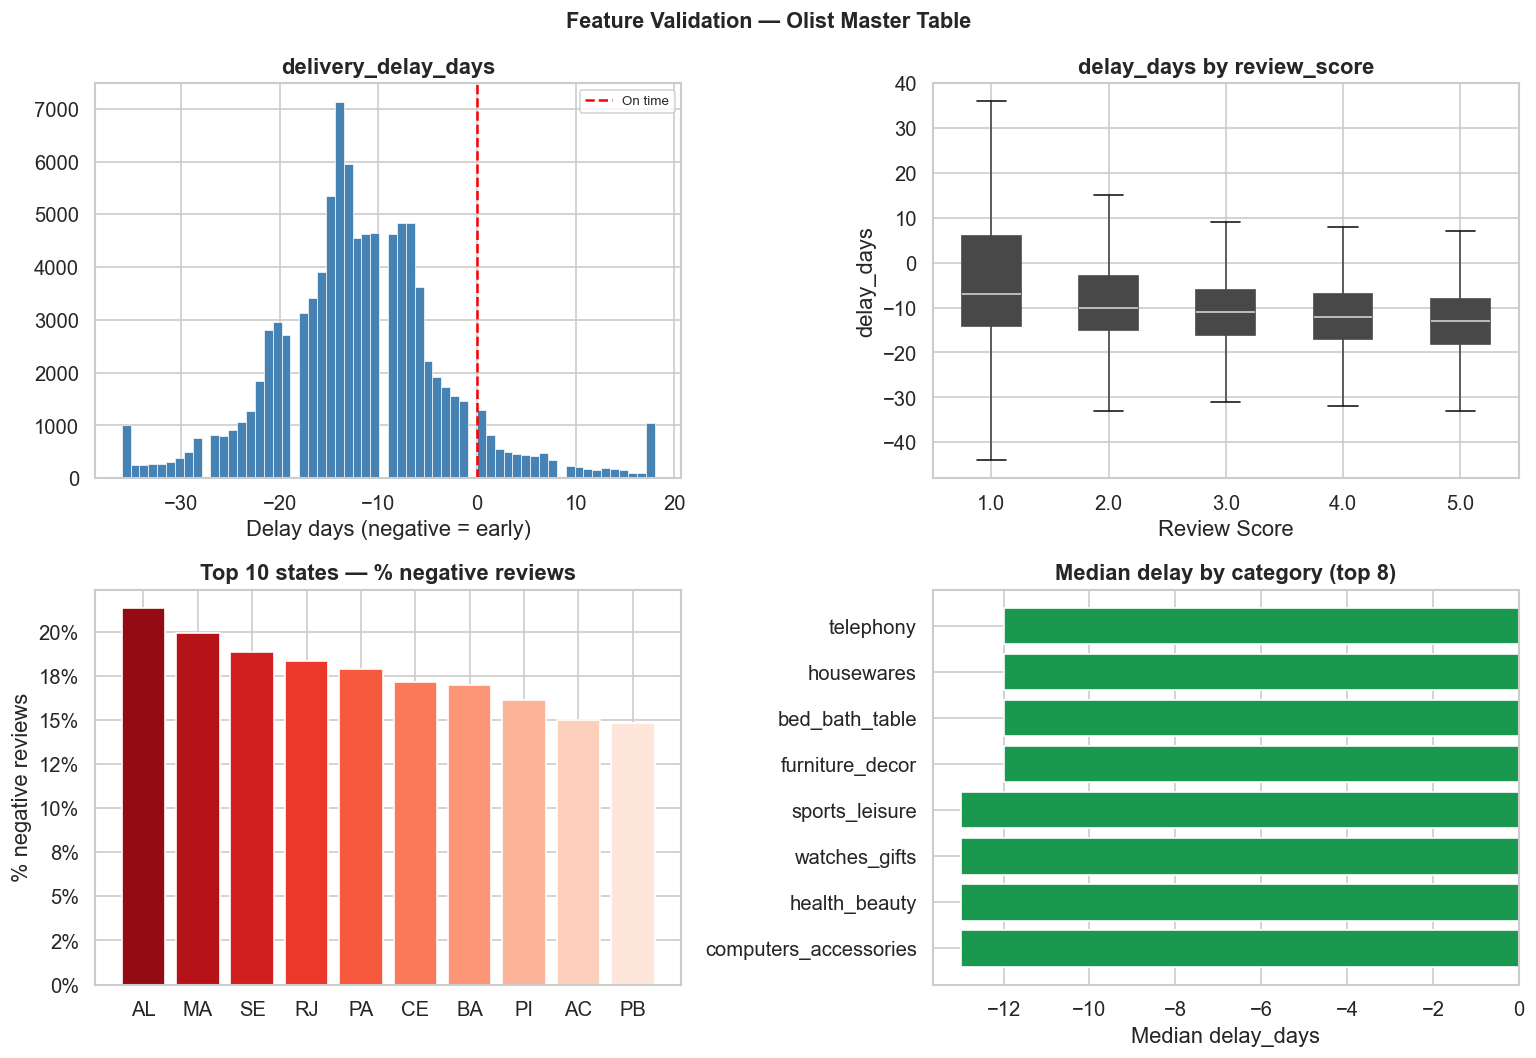

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# -- delivery_delay_days --
ax = axes[0, 0]
p1, p99 = master_final["delivery_delay_days"].quantile([0.01, 0.99])
clipped = master_final["delivery_delay_days"].clip(p1, p99)
ax.hist(clipped, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="On time")
ax.set_title("delivery_delay_days", fontweight="bold")
ax.set_xlabel("Delay days (negative = early)")
ax.legend(fontsize=8)

# -- review_score vs delivery_delay_days (boxplot) --
ax = axes[0, 1]
reviews_with_score = master_final.dropna(subset=["review_score", "delivery_delay_days"])
reviews_with_score.boxplot(
    column="delivery_delay_days",
    by="review_score",
    ax=ax,
    patch_artist=True,
    showfliers=False,
)
ax.set_title("delay_days by review_score", fontweight="bold")
ax.set_xlabel("Review Score")
ax.set_ylabel("delay_days")
plt.sca(ax)
plt.title("delay_days by review_score", fontweight="bold")

# -- is_negative_review by state --
ax = axes[1, 0]
neg_by_state = (
    master_final.dropna(subset=["is_negative_review"])
    .groupby("customer_state")["is_negative_review"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
ax.bar(neg_by_state.index, neg_by_state.values * 100,
       color=sns.color_palette("Reds_r", 10), edgecolor="white")
ax.set_title("Top 10 states — % negative reviews", fontweight="bold")
ax.set_ylabel("% negative reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# -- delivery_days by category (top 8) --
ax = axes[1, 1]
top_cats = master_final["category_en"].value_counts().head(8).index
cat_delay = (
    master_final[master_final["category_en"].isin(top_cats)]
    .groupby("category_en")["delivery_delay_days"]
    .median()
    .sort_values()
)
colors_cat = ["#d73027" if v > 0 else "#1a9850" for v in cat_delay.values]
ax.barh(cat_delay.index, cat_delay.values, color=colors_cat, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Median delay by category (top 8)", fontweight="bold")
ax.set_xlabel("Median delay_days")

plt.suptitle("Feature Validation — Olist Master Table", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "feature_validation.png", bbox_inches="tight")
plt.show()

---
## 7. Export master table to CSV
`data/olist_master.csv` is the entry point for the Phase 4 (Modeling) notebooks.
We export with `index=False` to avoid unnecessary index columns when reloading.

In [17]:
master_final.to_csv(OUT_CSV, index=False)

size_mb = OUT_CSV.stat().st_size / 1024 / 1024
print(f"Exported:  data/{OUT_CSV.name}")
print(f"Size:      {size_mb:.2f} MB")
print(f"Rows:      {len(master_final):,}")
print(f"Columns:   {len(master_final.columns)}")
print(f"\nColumns: {list(master_final.columns)}")

Exported:  data/olist_master.csv
Size:      17.74 MB
Rows:      96,457
Columns:   20

Columns: ['order_id', 'customer_unique_id', 'customer_state', 'customer_city', 'order_purchase_timestamp', 'order_month', 'order_weekday', 'order_hour', 'category_en', 'n_items', 'price_total', 'freight_total', 'freight_ratio', 'product_weight_g', 'delivery_days', 'delivery_delay_days', 'review_score', 'is_negative_review', 'review_creation_date', 'review_before_delivery']


---
## 8. Decision summary — Data Preparation

| Decision | Reason |
|----------|--------|
| Filter to `delivered` only | Only completed orders have a real delivery date to compute delay |
| Drop `delivery_days <= 0` | Corrupt data: delivery before the purchase is impossible |
| LEFT JOIN with reviews | Not every order has a review; imputing would bias the model |
| `is_negative_review` with threshold ≤ 2 | Scores 1–2 = clear dissatisfaction; score 3 is neutral in e-commerce |
| `category_en = 'unknown'` for nulls | Preserving uncategorized orders avoids losing business data |
| Not using `geolocation` | 261K duplicates and not needed for satisfaction modeling |
| `product_id = first()` in aggregation | Multi-product orders: we use the dominant product as a category proxy |

### Variables in the master table

| Variable | Type | Description |
|----------|------|-------------|
| `order_id` | ID | Primary key |
| `customer_unique_id` | ID | Actual customer (stable across orders) |
| `customer_state` | Categorical | Customer's state (Brazil) |
| `order_month` | Period | Purchase month (YYYY-MM) |
| `order_weekday` | Integer | Day of the week (0=Monday) |
| `order_hour` | Integer | Purchase hour |
| `category_en` | Categorical | Product category in English |
| `n_items` | Integer | Number of items in the order |
| `price_total` | Float | Total product value (BRL) |
| `freight_total` | Float | Total logistics cost (BRL) |
| `freight_ratio` | Float | freight / price (logistics ratio) |
| `product_weight_g` | Float | Main product's weight (g) |
| `delivery_days` | Integer | Days from purchase to delivery |
| `delivery_delay_days` | Integer | Delay vs. estimated date (+ = late) |
| `review_score` | Integer | Score 1–5 (NaN if no review) |
| `is_negative_review` | Binary | 1 if score ≤ 2, 0 if score ≥ 3, NaN if none |

### Next steps — Phase 4 (Modeling)
- Customer RFM segmentation (KMeans on Recency, Frequency, Monetary)
- Predicting `is_negative_review` (Logistic Regression / Random Forest)
- Feature importance analysis
